In [19]:
!pip install streamlit pyngrok -q
!pip install -q langgraph langgraph-checkpoint-sqlite langchain langchain-core langchain-groq

In [21]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph.message import add_messages
import sqlite3

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    groq_api_key=""
)

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

def chat_node(state: ChatState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

conn = sqlite3.connect(database='chatbot.db', check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

chatbot = graph.compile(checkpointer=checkpointer)

def retrieve_all_threads():
    all_threads = set()
    for checkpoint in checkpointer.list(None):
        all_threads.add(checkpoint.config['configurable']['thread_id'])
    return list(all_threads)

In [22]:
%%writefile langgraph_database_backend.py
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph.message import add_messages
import sqlite3

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    groq_api_key=""
)

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

def chat_node(state: ChatState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

conn = sqlite3.connect(database='chatbot.db', check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

chatbot = graph.compile(checkpointer=checkpointer)

def retrieve_all_threads():
    all_threads = set()
    for checkpoint in checkpointer.list(None):
        all_threads.add(checkpoint.config['configurable']['thread_id'])
    return list(all_threads)

Overwriting langgraph_database_backend.py


In [23]:
%%writefile app.py
import streamlit as st
from langgraph_database_backend import chatbot, retrieve_all_threads
from langchain_core.messages import HumanMessage
import uuid

def generate_thread_id():
    thread_id = uuid.uuid4()
    return thread_id

def reset_chat():
    thread_id = generate_thread_id()
    st.session_state['thread_id'] = thread_id
    add_thread(st.session_state['thread_id'])
    st.session_state['message_history'] = []

def add_thread(thread_id):
    if thread_id not in st.session_state['chat_threads']:
        st.session_state['chat_threads'].append(thread_id)

def load_conversation(thread_id):
    state = chatbot.get_state(config={'configurable': {'thread_id': thread_id}})
    return state.values.get('messages', [])

if 'message_history' not in st.session_state:
    st.session_state['message_history'] = []

if 'thread_id' not in st.session_state:
    st.session_state['thread_id'] = generate_thread_id()

if 'chat_threads' not in st.session_state:
    st.session_state['chat_threads'] = retrieve_all_threads()

add_thread(st.session_state['thread_id'])

st.sidebar.title('LangGraph Chatbot')

if st.sidebar.button('New Chat'):
    reset_chat()

st.sidebar.header('My Conversations')

for thread_id in st.session_state['chat_threads'][::-1]:
    if st.sidebar.button(str(thread_id)):
        st.session_state['thread_id'] = thread_id
        messages = load_conversation(thread_id)

        temp_messages = []
        for msg in messages:
            role = 'user' if isinstance(msg, HumanMessage) else 'assistant'
            temp_messages.append({'role': role, 'content': msg.content})

        st.session_state['message_history'] = temp_messages

for message in st.session_state['message_history']:
    with st.chat_message(message['role']):
        st.text(message['content'])

user_input = st.chat_input('Type here')

if user_input:
    st.session_state['message_history'].append({'role': 'user', 'content': user_input})
    with st.chat_message('user'):
        st.text(user_input)

    CONFIG = {
        "configurable": {"thread_id": st.session_state["thread_id"]},
        "metadata": {"thread_id": st.session_state["thread_id"]},
        "run_name": "chat_turn",
    }

    with st.chat_message('assistant'):
        ai_message = st.write_stream(
            message_chunk.content for message_chunk, metadata in chatbot.stream(
                {'messages': [HumanMessage(content=user_input)]},
                config=CONFIG,
                stream_mode='messages'
            )
        )

    st.session_state['message_history'].append({'role': 'assistant', 'content': ai_message})

Overwriting app.py


In [24]:
!streamlit run app.py &>/content/logs.txt &

from google.colab import userdata
from pyngrok import ngrok
import time

pyngrok_token = userdata.get('NGROK_AUTH_TOKEN')
ngrok.set_auth_token(pyngrok_token)

time.sleep(3)
public_url = ngrok.connect(addr=8501)
print(public_url)

NgrokTunnel: "https://thrower-curvature-rigid.ngrok-free.dev" -> "http://localhost:8501"


In [18]:
!sqlite3 chatbot.db ".tables"

/bin/bash: line 1: sqlite3: command not found


In [31]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("chatbot.db")

# Show all tables
print(pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
))

          name
0  checkpoints
1       writes


In [32]:
df = pd.read_sql_query("SELECT * FROM checkpoints", conn)

df

,thread_id,checkpoint_ns,checkpoint_id,parent_checkpoint_id,type,checkpoint,metadata
0,d4bc1f41-9960-4df1-9ad2-664dd6ef573c,,1f1786b1-a473-6e7f-bfff-62f505069e0e,None,msgpack,b'\x87\xa1v\x04\xa2ts\xd9 2026-07-05T12:14:42....,"b'{""source"": ""input"", ""step"": -1, ""parents"": {}}'"
1,d4bc1f41-9960-4df1-9ad2-664dd6ef573c,,1f1786b1-a47b-6379-8000-08859625d977,1f1786b1-a473-6e7f-bfff-62f505069e0e,msgpack,b'\x87\xa1v\x04\xa2ts\xd9 2026-07-05T12:14:42....,"b'{""source"": ""loop"", ""step"": 0, ""parents"": {}}'"
2,d4bc1f41-9960-4df1-9ad2-664dd6ef573c,,1f1786b1-a777-6cf3-8001-27b6b400c056,1f1786b1-a47b-6379-8000-08859625d977,msgpack,"b""\x87\xa1v\x04\xa2ts\xd9 2026-07-05T12:14:42....","b'{""source"": ""loop"", ""step"": 1, ""parents"": {}}'"
3,08945400-ac90-4aef-9b2a-e898ec7cc92e,,1f1786b2-911d-6302-bfff-ceec2669502a,None,msgpack,b'\x87\xa1v\x04\xa2ts\xd9 2026-07-05T12:15:07....,"b'{""source"": ""input"", ""step"": -1, ""parents"": {}}'"
4,08945400-ac90-4aef-9b2a-e898ec7cc92e,,1f1786b2-9126-65d3-8000-1c252d4870db,1f1786b2-911d-6302-bfff-ceec2669502a,msgpack,b'\x87\xa1v\x04\xa2ts\xd9 2026-07-05T12:15:07....,"b'{""source"": ""loop"", ""step"": 0, ""parents"": {}}'"
5,08945400-ac90-4aef-9b2a-e898ec7cc92e,,1f1786b2-944f-61e1-8001-6289d2869231,1f1786b2-9126-65d3-8000-1c252d4870db,msgpack,b'\x87\xa1v\x04\xa2ts\xd9 2026-07-05T12:15:07....,"b'{""source"": ""loop"", ""step"": 1, ""parents"": {}}'"
6,d4bc1f41-9960-4df1-9ad2-664dd6ef573c,,1f1786d9-3131-67e4-8002-f3ebdd96ddac,1f1786b1-a777-6cf3-8001-27b6b400c056,msgpack,"b""\x87\xa1v\x04\xa2ts\xd9 2026-07-05T12:32:23....","b'{""source"": ""input"", ""step"": 2, ""parents"": {}}'"
7,d4bc1f41-9960-4df1-9ad2-664dd6ef573c,,1f1786d9-3137-6837-8003-6b3e8a5b7a5d,1f1786d9-3131-67e4-8002-f3ebdd96ddac,msgpack,"b""\x87\xa1v\x04\xa2ts\xd9 2026-07-05T12:32:23....","b'{""source"": ""loop"", ""step"": 3, ""parents"": {}}'"
8,d4bc1f41-9960-4df1-9ad2-664dd6ef573c,,1f1786d9-4436-6bba-8004-951d90950d69,1f1786d9-3137-6837-8003-6b3e8a5b7a5d,msgpack,"b""\x87\xa1v\x04\xa2ts\xd9 2026-07-05T12:32:25....","b'{""source"": ""loop"", ""step"": 4, ""parents"": {}}'"


In [35]:
state = chatbot.get_state(
    config={"configurable": {"thread_id": "08945400-ac90-4aef-9b2a-e898ec7cc92e"}}
)

print(state.values["messages"])

[HumanMessage(content='wow', additional_kwargs={}, response_metadata={}, id='c4821204-09e1-489c-88a9-9309c1d99068'), AIMessage(content='That\'s quite a reaction. What\'s got you saying "wow"? Want to talk about it?', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'model_provider': 'groq'}, id='lc_run--019f3234-2968-7203-b0ad-a2c84ec36013', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 21, 'total_tokens': 57})]


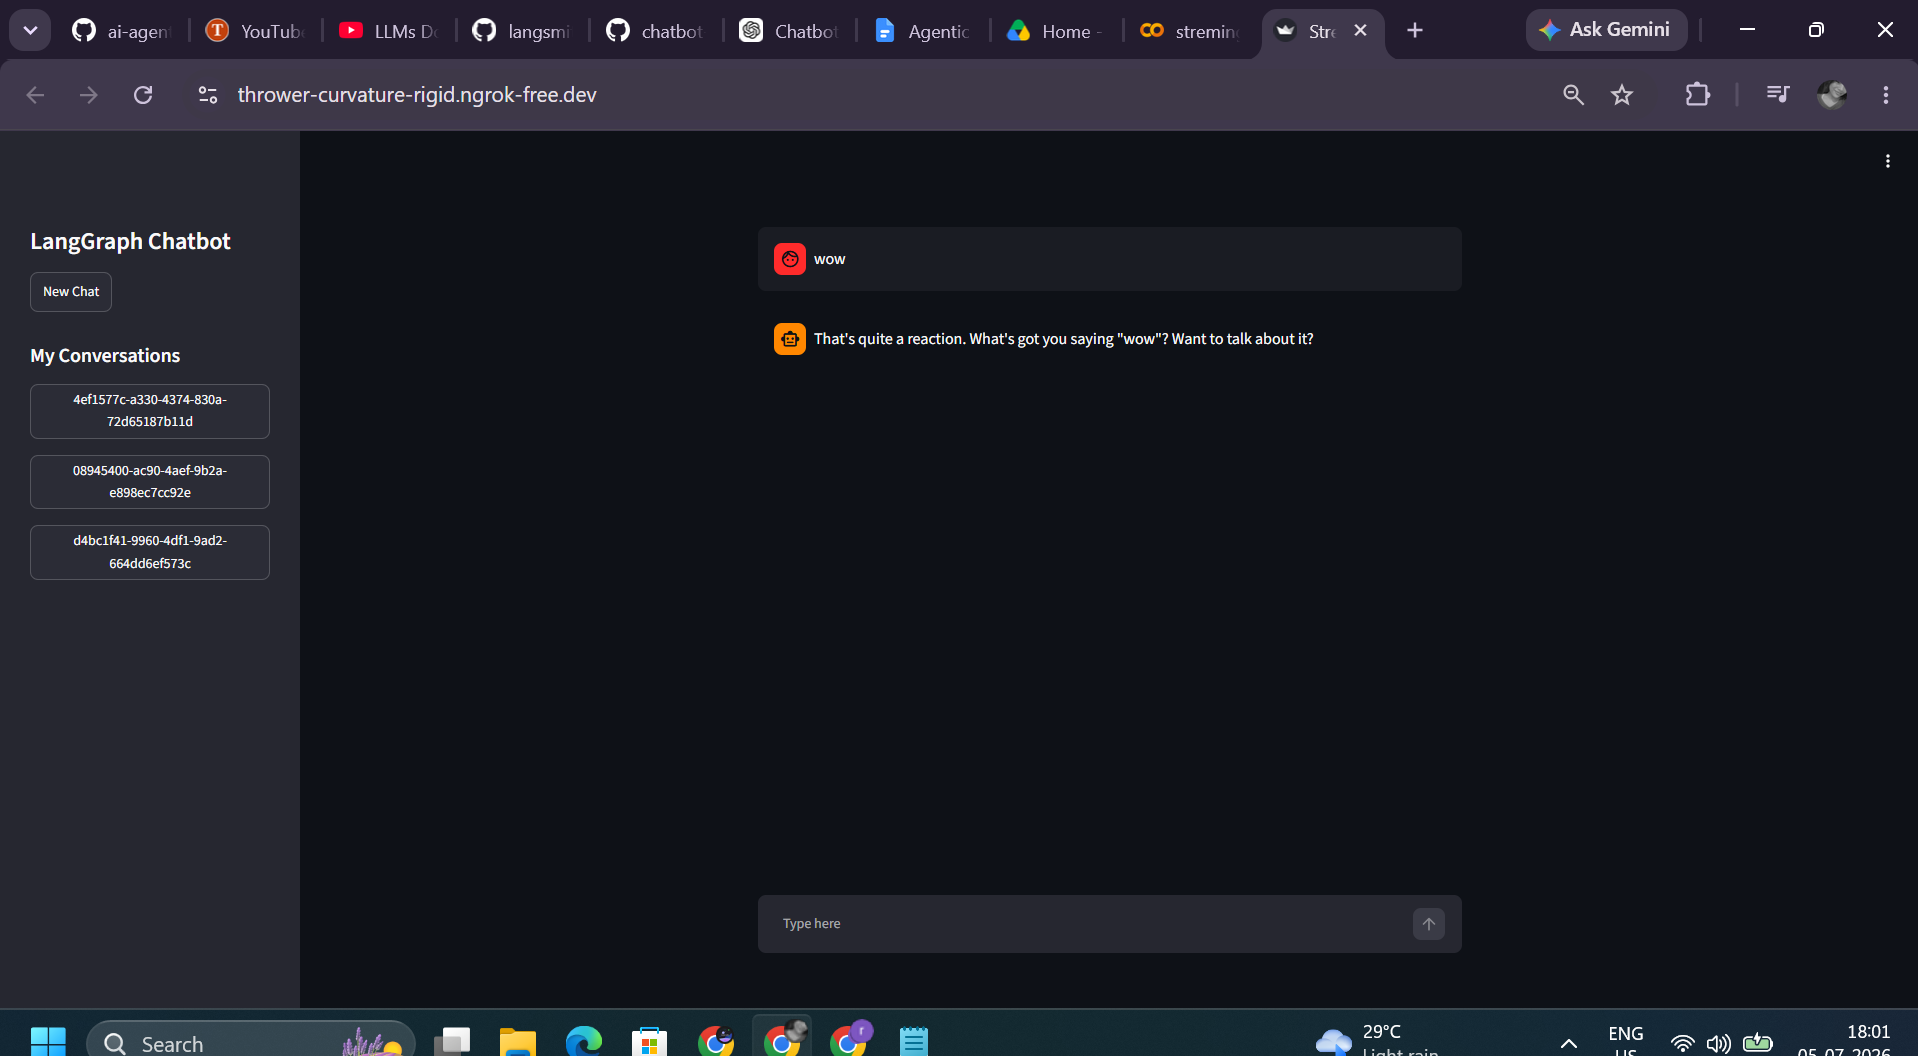

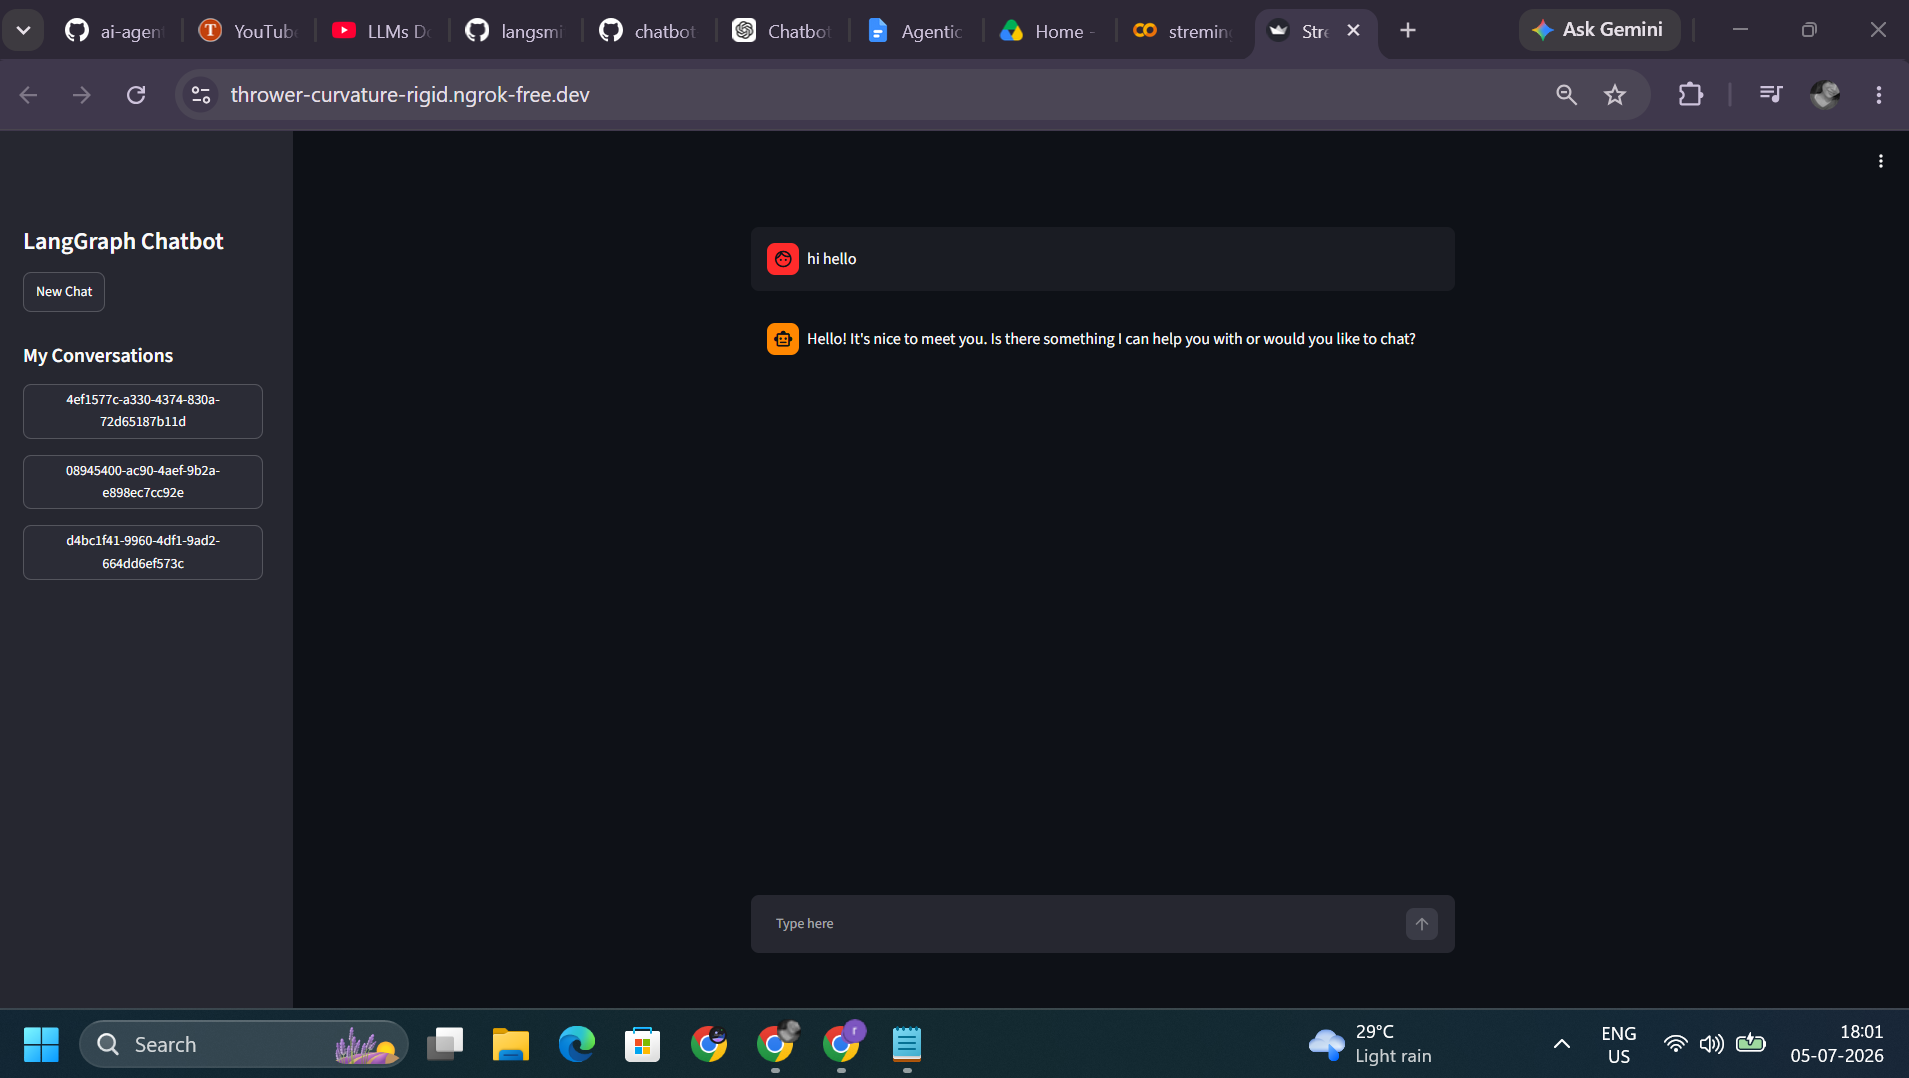